# 07 - VUS Model Training (Trusted Labels Only)

Train a binary classifier on trusted labels only:
- Positive: Pathogenic + Likely pathogenic
- Negative: Benign + Likely benign

VUS rows are intentionally excluded from training and scored later.

In [6]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
REPORTS_DIR = ROOT / 'reports'
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

IN_X = DATA_DIR / 'vus_trusted_X.parquet'
IN_Y = DATA_DIR / 'vus_trusted_y.csv'
IN_G = DATA_DIR / 'vus_trusted_groups.csv'

OUT_MODEL = MODELS_DIR / 'vus_ranker.joblib'
OUT_METRICS = REPORTS_DIR / 'vus_model_metrics.json'
OUT_IMPORTANCE = REPORTS_DIR / 'vus_feature_importance.csv'

print('ROOT:', ROOT)

ROOT: C:\Users\lvrga\OneDrive\work\predtest


In [7]:
X = pd.read_parquet(IN_X)
y = pd.read_csv(IN_Y)['y'].astype(int)
groups = pd.read_csv(IN_G)['trio_id'].astype(str)

print('X shape:', X.shape)
print('y mean :', round(float(y.mean()), 4))
print('n groups:', groups.nunique())

if X.empty:
    raise ValueError('Trusted feature table is empty.')
if groups.nunique() < 2:
    raise ValueError('Need at least 2 distinct trio groups for GroupKFold.')

X shape: (50, 38)
y mean : 1.0
n groups: 14


In [10]:
numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop'
)

try:
    from lightgbm import LGBMClassifier
    clf = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    chosen_model = 'LGBMClassifier'
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    )
    chosen_model = 'RandomForestClassifier'

pipe = Pipeline(steps=[('preprocess', preprocess), ('clf', clf)])
print('Chosen model:', chosen_model)
print('Numeric features:', len(numeric_cols), '| Categorical features:', len(categorical_cols))

Chosen model: RandomForestClassifier
Numeric features: 38 | Categorical features: 0


{
  "model": "RandomForestClassifier (single-class fallback)",
  "n_rows": 50,
  "n_features": 38,
  "n_groups": 14,
  "cv_splits": 5,
  "positive_rate": 1.0,
  "roc_auc_oof": null,
  "average_precision_oof": null,
  "brier_oof": 0.0
}


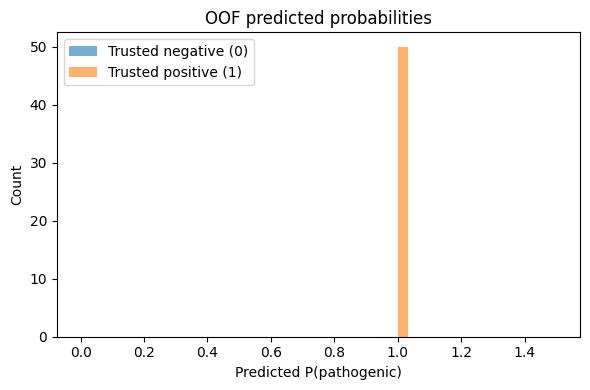

In [11]:
single_class_mode = (y.nunique() < 2)
if single_class_mode:
    only_class = int(y.iloc[0])
    print(f'Warning: trusted labels contain only one class ({only_class}). Falling back to single-class training mode.')

n_splits = min(5, groups.nunique())
if n_splits < 2 and not single_class_mode:
    raise ValueError('Need at least 2 distinct trio groups for GroupKFold.')

if single_class_mode:
    oof_proba = np.full(len(X), float(only_class), dtype=float)
    metrics = {
        'model': f'{chosen_model} (single-class fallback)',
        'n_rows': int(len(X)),
        'n_features': int(X.shape[1]),
        'n_groups': int(groups.nunique()),
        'cv_splits': int(max(1, n_splits)),
        'positive_rate': float(y.mean()),
        'roc_auc_oof': None,
        'average_precision_oof': None,
        'brier_oof': float(brier_score_loss(y, oof_proba)),
    }
else:
    cv = GroupKFold(n_splits=n_splits)
    oof_proba = np.full(len(X), np.nan, dtype=float)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        est = clone(pipe)
        est.fit(X_train, y_train)

        proba = est.predict_proba(X_test)
        classes = est.named_steps['clf'].classes_

        if proba.shape[1] == 1:
            # Some folds can become single-class with small cohorts; map that class to 0/1 probability.
            only_fold_class = int(classes[0])
            fold_proba = np.ones(len(test_idx), dtype=float) if only_fold_class == 1 else np.zeros(len(test_idx), dtype=float)
        else:
            pos_idx = np.where(classes == 1)[0]
            if len(pos_idx) != 1:
                raise RuntimeError(f'Could not locate positive class in classes={classes}')
            fold_proba = proba[:, int(pos_idx[0])]

        oof_proba[test_idx] = fold_proba

    if np.isnan(oof_proba).any():
        raise RuntimeError('Some OOF probabilities were not filled.')

    metrics = {
        'model': chosen_model,
        'n_rows': int(len(X)),
        'n_features': int(X.shape[1]),
        'n_groups': int(groups.nunique()),
        'cv_splits': int(n_splits),
        'positive_rate': float(y.mean()),
        'roc_auc_oof': float(roc_auc_score(y, oof_proba)),
        'average_precision_oof': float(average_precision_score(y, oof_proba)),
        'brier_oof': float(brier_score_loss(y, oof_proba)),
    }

print(json.dumps(metrics, indent=2))

plt.figure(figsize=(6, 4))
plt.hist(oof_proba[y == 0], bins=30, alpha=0.6, label='Trusted negative (0)')
plt.hist(oof_proba[y == 1], bins=30, alpha=0.6, label='Trusted positive (1)')
plt.title('OOF predicted probabilities')
plt.xlabel('Predicted P(pathogenic)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
if single_class_mode:
    from sklearn.dummy import DummyClassifier
    fallback_clf = DummyClassifier(strategy='prior')
    final_pipe = Pipeline(steps=[('preprocess', preprocess), ('clf', fallback_clf)])
    final_pipe.fit(X, y)
else:
    final_pipe = pipe
    final_pipe.fit(X, y)

import joblib
joblib.dump(final_pipe, OUT_MODEL)
with open(OUT_METRICS, 'w', encoding='utf-8') as fh:
    json.dump(metrics, fh, indent=2)

clf_fitted = final_pipe.named_steps['clf']
if hasattr(clf_fitted, 'feature_importances_'):
    feat_names = final_pipe.named_steps['preprocess'].get_feature_names_out()
    fi = pd.DataFrame({
        'feature': feat_names,
        'importance': clf_fitted.feature_importances_
    }).sort_values('importance', ascending=False)
    fi.to_csv(OUT_IMPORTANCE, index=False)
    display(fi.head(20))

print('Saved model   :', OUT_MODEL)
print('Saved metrics :', OUT_METRICS)
print('Saved FI table:', OUT_IMPORTANCE if OUT_IMPORTANCE.exists() else 'not available for this model')

Saved model   : C:\Users\lvrga\OneDrive\work\predtest\models\vus_ranker.joblib
Saved metrics : C:\Users\lvrga\OneDrive\work\predtest\reports\vus_model_metrics.json
Saved FI table: not available for this model
